# Gen 1: From Forecast to Cash Flow and DSCR

**Purpose:** Implement the minimal Gen 1 DSCR model from the methodology note  
`docs/From_Forecast_to_Cashflow_and_DSCR.md` (§5.3, §7).

**What this notebook does:**
1. Loads annual revenue paths from GCS `aggregated_data/{site}/revenue.duckdb` (hub + DA, eligible paths only)
2. Computes P10 / P25 / P50 / P75 / P90 annual revenue from the eligible distribution
3. Applies flat OpEx → CFADS = Revenue − OpEx (constant every year, Gen 1 assumption)
4. Builds a simple loan amortization schedule (level payment or level principal)
5. Computes annual DSCR for each percentile over the loan tenor
6. Flags covenant breach (DSCR < minimum) and plots results

**Scope:** Hub + DA only. Single asset (configurable). No degradation, no escalation — Gen 1.

**Data source:** `gs://infrasure-model-gpr-data/aggregated_data/{site}/revenue.duckdb`  
- Table: `annual`  
- Key columns: `kind`, `market`, `annual_revenue_usd`, `eligible_for_rev_dist`  
- Filter: `kind = 'hub'`, `market = 'da'`, `eligible_for_rev_dist = TRUE`

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import io
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import duckdb
from google.cloud import storage

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries loaded OK")

Libraries loaded OK


---
## 1. Configuration

All user-editable parameters are in this one cell.

In [ ]:
# ── GCS ──────────────────────────────────────────────────────────────────────
GCS_PROJECT   = "infrasure-model-gpr"
GCS_BUCKET    = "infrasure-model-gpr-data"
SITE          = "ash_creek_solar"   # asset_slug from asset_registry.duckdb

# ── Data filter ──────────────────────────────────────────────────────────────
KIND          = "hub"   # hub or node
MARKET        = "da"    # da or rt
# Only eligible_for_rev_dist=TRUE paths are used (adequate price coverage)

# ── Loan terms (Gen 1 inputs) ────────────────────────────────────────────────
LOAN_PRINCIPAL   = 50_000_000   # $ principal at COD (term loan)
ANNUAL_RATE      = 0.06         # annual interest rate (nominal, fixed)
TENOR_YEARS      = 18           # loan tenor from COD
AMORT_TYPE       = "level_principal"  # "level_payment"  → constant DS, flat DSCR
                                       # "level_principal" → DS declines, DSCR improves ← matches doc §5.3
                                       # "sculpted"        → DS = CFADS/target_DSCR, constant DSCR (Gen 2 meaningful)

# ── Sculpted-specific (used only when AMORT_TYPE = "sculpted") ────────────────
TARGET_DSCR_SCULPT = 1.40   # target DSCR to sculpt debt service around
SCULPT_PERCENTILE  = "P50"  # which revenue percentile defines base CFADS for sculpting

# ── OpEx — derived from registry capacity after lookup (override if needed) ──────
# Source: NREL ATB 2024 (docs/extra/discussions/project_finance_opex.md)
#   Solar all-in: $22–25/kWAC-yr  →  using $23k/MW-yr
#   Wind  all-in: $43–48/kW-yr   →  using $45k/MW-yr

# Escalation rate (Gen 1: 0.0 = flat; Gen 2: 0.025 = 2.5%/yr industry standard)
# Source: industry standard 2.0–2.5%/yr (docs/extra/discussions/project_finance_opex.md)
# When > 0: OpEx(t) = ANNUAL_OPEX * (1 + OPEX_ESCALATION_RATE) ** (t - 1)
OPEX_ESCALATION_RATE = 0.0   # 0.0 = flat (Gen 1); set 0.025 for Gen 2
OPEX_PER_KW = {
    "solar":   23_000,   # $/MW-yr  ($23/kW) — NREL ATB 2024 solar
    "wind":    45_000,   # $/MW-yr  ($45/kW) — NREL ATB 2024 wind
    "battery": 40_000,   # $/MW-yr  (~2.5–4% capex proxy)
}
ANNUAL_OPEX_OVERRIDE = None   # set e.g. 4_000_000 to hard-override derived value

# ── DSCR covenant — derived from technology after lookup (override if needed) ─────
# Source: Norton Rose Fulbright 2024 via NREL ATB
MIN_DSCR_BY_TYPE = {
    "solar":   1.25,   # P50 target for utility-scale solar
    "wind":    1.35,   # P50 target for onshore wind (higher resource variability)
    "battery": 2.00,   # P50 target for BESS (revenue stream uncertainty)
}
MIN_DSCR_OVERRIDE = None   # set e.g. 1.30 to hard-override derived value

# ── Percentiles to compute ───────────────────────────────────────────────────
PERCENTILES      = [10, 25, 50, 75, 90]

print(f"Site: {SITE}  (run next cell to validate against asset registry)")
print(f"Filter: kind={KIND}, market={MARKET}, eligible only")
print(f"Loan: ${LOAN_PRINCIPAL:,.0f} at {ANNUAL_RATE*100:.1f}%, {TENOR_YEARS}yr, {AMORT_TYPE}")
if AMORT_TYPE == "sculpted":
    print(f"  Sculpted: target DSCR={TARGET_DSCR_SCULPT}x, base CFADS={SCULPT_PERCENTILE}")
print(f"OpEx override: {ANNUAL_OPEX_OVERRIDE}  (None = auto from capacity)")
print(f"MIN_DSCR override: {MIN_DSCR_OVERRIDE}  (None = auto from asset type)")

Site: ash_creek_solar
Filter: kind=hub, market=da, eligible only
Loan: $50,000,000 at 6.0%, 18yr, level_principal
OpEx: $4,000,000/yr (flat)
DSCR covenant: ≥ 1.25x


---
## 1b. Asset Registry Lookup

Download `asset_registry.duckdb` from GCS root, query the `asset` + `solar_asset`/`wind_asset`
tables to validate that `SITE` exists, retrieve `AC_CAPACITY_MW` and `ASSET_TYPE`,
then resolve `ANNUAL_OPEX` and `MIN_DSCR` from the dicts defined in the config cell above.

**Why this matters:**
- `AC_CAPACITY_MW` → OpEx = capacity × per-kW rate (sourced from NREL ATB 2024)  
- `ASSET_TYPE` → technology-appropriate MIN_DSCR default (solar 1.25x / wind 1.35x)  
- Validates `SITE` exists in registry before spending time on a GCS revenue download  
- `available_sites` DataFrame = future dashboard site dropdown

In [ ]:
def load_asset_registry(bucket_name: str, project: str) -> dict:
    """Download asset_registry.duckdb from GCS root and return metadata for SITE."""
    client = storage.Client(project=project)
    blob   = client.bucket(bucket_name).blob("asset_registry.duckdb")
    tmp    = tempfile.NamedTemporaryFile(suffix=".duckdb", delete=False)
    tmp.close()
    blob.reload()
    print(f"Downloading gs://{bucket_name}/asset_registry.duckdb "
          f"({blob.size / 1024:.0f} KB)...")
    blob.download_to_filename(tmp.name)
    print("Download complete.")

    con = duckdb.connect(tmp.name, read_only=True)

    # All available slugs (for future site dropdown)
    available = con.execute(
        "SELECT asset_slug, asset_type, state "
        "FROM asset ORDER BY asset_type, asset_slug"
    ).fetchdf()

    # Metadata for the requested SITE
    row = con.execute("""
        SELECT a.asset_slug, a.asset_type, a.state,
               COALESCE(s.ac_capacity_mw, w.ac_capacity_mw) AS ac_capacity_mw
        FROM asset a
        LEFT JOIN solar_asset s USING (asset_id)
        LEFT JOIN wind_asset  w USING (asset_id)
        WHERE a.asset_slug = ?
    """, [SITE]).fetchone()

    con.close()
    os.unlink(tmp.name)

    if row is None:
        raise ValueError(
            f"SITE '{SITE}' not found in asset_registry.\n"
            f"Available slugs:\n{available['asset_slug'].tolist()}"
        )

    return {
        "asset_slug":     row[0],
        "asset_type":     row[1],
        "state":          row[2],
        "ac_capacity_mw": float(row[3]) if row[3] is not None else None,
        "available_sites": available,
    }


# ── Execute ──────────────────────────────────────────────────────────────────
asset_meta     = load_asset_registry(GCS_BUCKET, GCS_PROJECT)
AC_CAPACITY_MW = asset_meta["ac_capacity_mw"]
ASSET_TYPE     = asset_meta["asset_type"]

# ── Resolve ANNUAL_OPEX ───────────────────────────────────────────────────────
if ANNUAL_OPEX_OVERRIDE is not None:
    ANNUAL_OPEX  = ANNUAL_OPEX_OVERRIDE
    _opex_source = "manual override"
elif AC_CAPACITY_MW is not None and ASSET_TYPE in OPEX_PER_KW:
    ANNUAL_OPEX  = AC_CAPACITY_MW * OPEX_PER_KW[ASSET_TYPE]
    _opex_source = (
        f"{ASSET_TYPE} {OPEX_PER_KW[ASSET_TYPE]:,}/MW-yr × {AC_CAPACITY_MW:.1f} MW "
        f"— NREL ATB 2024"
    )
else:
    ANNUAL_OPEX  = 4_000_000
    _opex_source = "fallback default (capacity or type unknown)"

# ── Resolve MIN_DSCR ──────────────────────────────────────────────────────────
if MIN_DSCR_OVERRIDE is not None:
    MIN_DSCR      = MIN_DSCR_OVERRIDE
    _dscr_source  = "manual override"
else:
    MIN_DSCR      = MIN_DSCR_BY_TYPE.get(ASSET_TYPE, 1.25)
    _dscr_source  = f"{ASSET_TYPE} default — Norton Rose Fulbright 2024"

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nAsset resolved:")
print(f"  Site      : {SITE}")
print(f"  Type      : {ASSET_TYPE}")
print(f"  State     : {asset_meta['state']}")
print(f"  AC cap    : {AC_CAPACITY_MW:.1f} MW" if AC_CAPACITY_MW else "  AC cap    : unknown")
print(f"  OpEx      : ${ANNUAL_OPEX:,.0f}/yr  ({_opex_source})")
print(f"  MIN_DSCR  : {MIN_DSCR}x  ({_dscr_source})")
print(f"\nAll available sites ({len(asset_meta['available_sites'])}):",
      asset_meta['available_sites']['asset_slug'].tolist())

---
## 2. Load Revenue Data from GCS

Download `aggregated_data/{site}/revenue.duckdb`, query the `annual` table,  
and filter to **hub + DA + eligible paths only**.

In [16]:
def download_revenue_duckdb(bucket_name: str, site: str, project: str) -> str:
    """Download revenue.duckdb for a site to a temp file. Returns temp path."""
    gcs_path = f"aggregated_data/{site}/revenue.duckdb"
    client = storage.Client(project=project)
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)
    if not blob.exists():
        raise FileNotFoundError(f"Not found in GCS: gs://{bucket_name}/{gcs_path}")
    blob.reload()  # fetch metadata so blob.size is populated
    tmp = tempfile.NamedTemporaryFile(suffix=".duckdb", delete=False)
    tmp.close()
    print(f"Downloading gs://{bucket_name}/{gcs_path} ({blob.size/1024:.0f} KB)...")
    blob.download_to_filename(tmp.name)
    print("Download complete.")
    return tmp.name


def load_annual_revenue(db_path: str, kind: str, market: str) -> pd.DataFrame:
    """Query the annual table and return eligible hub/da rows."""
    con = duckdb.connect(db_path, read_only=True)
    df = con.execute("""
        SELECT path_id, segment, source_year, annual_revenue_usd,
               price_per_mwh_gen_weighted, revenue_coverage_pct
        FROM annual
        WHERE kind    = ?
          AND market  = ?
          AND eligible_for_rev_dist = TRUE
          AND annual_revenue_usd IS NOT NULL
        ORDER BY path_id
    """, [kind, market]).df()
    con.close()
    return df


# ── Execute ───────────────────────────────────────────────────────────────────
db_path = download_revenue_duckdb(GCS_BUCKET, SITE, GCS_PROJECT)
annual_df = load_annual_revenue(db_path, KIND, MARKET)
os.unlink(db_path)   # clean up temp file

print(f"\nEligible paths loaded: {len(annual_df):,}")
print(f"Segments: {annual_df['segment'].value_counts().to_dict()}")
annual_df.head(5)

Download complete.

Eligible paths loaded: 114
Segments: {'simulated': 100, 'historical': 14}


,path_id,segment,source_year,annual_revenue_usd,price_per_mwh_gen_weighted,revenue_coverage_pct
0,2011,historical,2011,4.093123e+07,50.603157,100.0
1,2012,historical,2012,2.573215e+07,33.047613,100.0
2,2013,historical,2013,2.844438e+07,37.037314,100.0
3,2014,historical,2014,3.045634e+07,40.887825,100.0
4,2015,historical,2015,2.328796e+07,32.398615,100.0


### 2a. Schema inspection

Quick look at the revenue distribution across eligible paths.

=== Revenue distribution (eligible hub/da paths) ===
count           $114
mean     $28,152,806
std       $4,323,371
min      $19,653,328
25%      $25,221,875
50%      $27,565,915
75%      $30,382,881
max      $43,239,983
Name: annual_revenue_usd, dtype: str


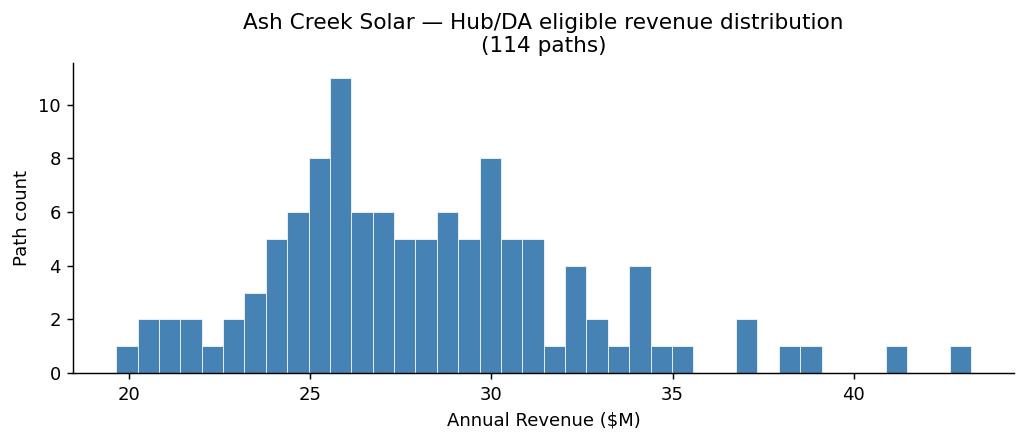

In [17]:
print("=== Revenue distribution (eligible hub/da paths) ===")
print(annual_df["annual_revenue_usd"].describe().apply(lambda x: f"${x:,.0f}"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(annual_df["annual_revenue_usd"] / 1e6, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Annual Revenue ($M)")
ax.set_ylabel("Path count")
ax.set_title(f"{SITE.replace('_', ' ').title()} — Hub/DA eligible revenue distribution\n"
             f"({len(annual_df):,} paths)")
plt.tight_layout()
plt.show()

---
## 3. Gen 1 Inputs

Compute P10 / P25 / P50 / P75 / P90 from the **eligible simulated paths only**  
(segment = 'simulated'), then apply flat OpEx to get CFADS.

> **Why simulated only?** Historical paths represent 2021–2024 actuals (4 years).  
> The 1,000 simulated paths are the bootstrap forecast distribution — these are the  
> correct source for P10/P90 percentile revenue for project finance analysis.

In [ ]:
# ── Use simulated paths for the forecast distribution ────────────────────────
sim_df = annual_df[annual_df["segment"] == "simulated"].copy()
print(f"Simulated eligible paths: {len(sim_df):,}")

# ── Compute percentile revenues ───────────────────────────────────────────────
pct_revenue = {
    f"P{p}": float(np.percentile(sim_df["annual_revenue_usd"], p))
    for p in PERCENTILES
}

print("\n=== Annual Revenue at each percentile (hub / DA) ===")
for label, val in pct_revenue.items():
    print(f"  {label}: ${val:>14,.0f}")

# ── CFADS = Revenue − OpEx (flat, same every year — Gen 1 assumption) ─────────
pct_cfads = {
    label: rev - ANNUAL_OPEX
    for label, rev in pct_revenue.items()
}

print(f"\nFlat OpEx: ${ANNUAL_OPEX:,.0f}/yr")
print("\n=== CFADS at each percentile ===")
for label, val in pct_cfads.items():
    flag = "  ⚠️ NEGATIVE CFADS" if val <= 0 else ""
    print(f"  {label}: ${val:>14,.0f}{flag}")

Simulated eligible paths: 100

=== Annual Revenue at each percentile (hub / DA) ===
  P10: $    23,920,946
  P25: $    25,337,980
  P50: $    27,565,915
  P75: $    30,380,230
  P90: $    33,716,756

Flat OpEx: $4,000,000/yr

=== CFADS at each percentile ===
  P10: $    19,920,946
  P25: $    21,337,980
  P50: $    23,565,915
  P75: $    26,380,230
  P90: $    29,716,756


---
## 4. Loan Amortization Schedule

Build annual debt service schedule over the full loan tenor.  
Supports **level payment** (annuity), **level principal**, and **sculpted**.

- **Level payment:** same total payment each year; principal share grows over time.
- **Level principal:** same principal each year; total payment declines. DSCR improves as DS falls.
- **Sculpted:** DS set to `CFADS / target_DSCR` each year. Produces constant DSCR. Requires a base CFADS series.  
  In Gen 1 (flat CFADS), sculpted is numerically identical to level payment. The difference emerges in Gen 2 when CFADS varies year-by-year (degradation + escalation). See `docs/From_Forecast_to_Cashflow_and_DSCR.md §4a`.

From doc §4: `Debt Service = Interest + Principal`.

In [ ]:
def build_amortization(
    principal: float,
    annual_rate: float,
    tenor_years: int,
    amort_type: str = "level_payment",
    cfads_series=None,       # required for sculpted: flat scalar OR list of per-year values
    target_dscr: float = 1.40,  # target DSCR for sculpted branch
) -> pd.DataFrame:
    """
    Build annual loan amortization schedule.

    Supports:
      - level_payment:   same total DS each year (annuity)
      - level_principal: same principal each year; DS declines
      - sculpted:        DS(t) = cfads(t) / target_dscr; produces constant DSCR
                         Pass cfads_series as a scalar (flat) or list (per-year, for Gen 2).
                         In Gen 1 with flat CFADS, sculpted == level_payment numerically.

    Returns DataFrame with columns:
        year, opening_balance, interest, principal, debt_service, closing_balance
    """
    rows = []
    balance = principal

    if amort_type == "level_payment":
        # Annuity formula: same total payment each year
        r = annual_rate
        n = tenor_years
        annual_payment = principal * (r * (1 + r) ** n) / ((1 + r) ** n - 1)

        for t in range(1, tenor_years + 1):
            interest      = balance * annual_rate
            principal_pmt = annual_payment - interest
            closing       = balance - principal_pmt
            rows.append({
                "year": t,
                "opening_balance": balance,
                "interest": interest,
                "principal": principal_pmt,
                "debt_service": annual_payment,
                "closing_balance": max(closing, 0.0),
            })
            balance = max(closing, 0.0)

    elif amort_type == "level_principal":
        # Same principal each year; interest declines
        principal_pmt = principal / tenor_years

        for t in range(1, tenor_years + 1):
            interest     = balance * annual_rate
            debt_service = principal_pmt + interest
            closing      = balance - principal_pmt
            rows.append({
                "year": t,
                "opening_balance": balance,
                "interest": interest,
                "principal": principal_pmt,
                "debt_service": debt_service,
                "closing_balance": max(closing, 0.0),
            })
            balance = max(closing, 0.0)

    elif amort_type == "sculpted":
        # DS(t) = cfads(t) / target_dscr  ->  Principal(t) = DS(t) - Interest(t)
        # Flat scalar input for Gen 1; per-year list for Gen 2 (degradation + escalation).
        if cfads_series is None:
            raise ValueError(
                "cfads_series is required for sculpted amortization. "
                "Pass pct_cfads[SCULPT_PERCENTILE] (flat scalar in Gen 1, "
                "or a per-year list in Gen 2)."
            )
        if isinstance(cfads_series, (int, float)):
            cfads_series = [float(cfads_series)] * tenor_years

        for t, cfads_t in enumerate(cfads_series, start=1):
            interest      = balance * annual_rate
            ds            = cfads_t / target_dscr
            principal_pmt = ds - interest
            closing       = balance - principal_pmt
            rows.append({
                "year": t,
                "opening_balance": balance,
                "interest": interest,
                "principal": principal_pmt,
                "debt_service": ds,
                "closing_balance": max(closing, 0.0),
            })
            balance = max(closing, 0.0)

    else:
        raise ValueError(
            f"Unknown amort_type: {amort_type!r}. "
            "Use 'level_payment', 'level_principal', or 'sculpted'."
        )

    return pd.DataFrame(rows).set_index("year")


# ── Build active schedule ────────────────────────────────────────────────────────────────────────────────
_sculpt_cfads = pct_cfads.get(SCULPT_PERCENTILE) if AMORT_TYPE == "sculpted" else None
loan_schedule = build_amortization(
    LOAN_PRINCIPAL, ANNUAL_RATE, TENOR_YEARS, AMORT_TYPE,
    cfads_series=_sculpt_cfads,
    target_dscr=TARGET_DSCR_SCULPT,
)

print(f"=== Loan Schedule ({AMORT_TYPE}) ===")
print(f"Principal: ${LOAN_PRINCIPAL:,.0f} | Rate: {ANNUAL_RATE*100:.1f}% | Tenor: {TENOR_YEARS}yr")
if AMORT_TYPE == "sculpted":
    print(f"Sculpted: base CFADS={SCULPT_PERCENTILE} (${_sculpt_cfads:,.0f}/yr) | target DSCR={TARGET_DSCR_SCULPT}x")
print()
display_cols = ["opening_balance", "interest", "principal", "debt_service", "closing_balance"]
loan_schedule[display_cols].style.format("${:,.0f}")

=== Loan Schedule (level_principal) ===
Principal: $50,000,000 | Rate: 6.0% | Tenor: 18yr



,opening_balance,interest,principal,debt_service,closing_balance
year,,,,,
1,"$50,000,000","$3,000,000","$2,777,778","$5,777,778","$47,222,222"
2,"$47,222,222","$2,833,333","$2,777,778","$5,611,111","$44,444,444"
3,"$44,444,444","$2,666,667","$2,777,778","$5,444,444","$41,666,667"
4,"$41,666,667","$2,500,000","$2,777,778","$5,277,778","$38,888,889"
5,"$38,888,889","$2,333,333","$2,777,778","$5,111,111","$36,111,111"
6,"$36,111,111","$2,166,667","$2,777,778","$4,944,444","$33,333,333"
7,"$33,333,333","$2,000,000","$2,777,778","$4,777,778","$30,555,556"
8,"$30,555,556","$1,833,333","$2,777,778","$4,611,111","$27,777,778"
9,"$27,777,778","$1,666,667","$2,777,778","$4,444,444","$25,000,000"


### 4a. Debt service profile

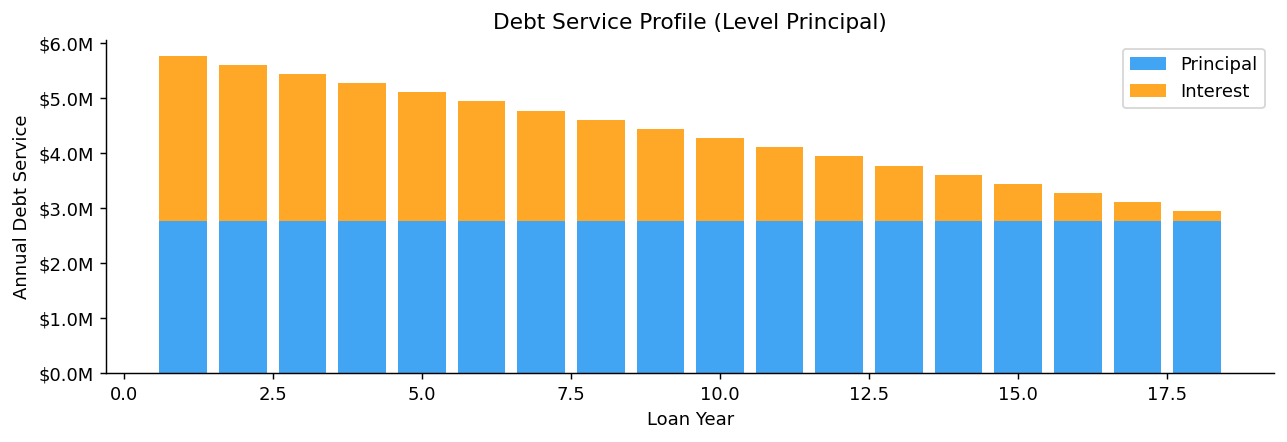

In [20]:
# ── Compute all three schedules for comparison ────────────────────────────────────────────
_p50_cfads   = pct_cfads["P50"]
_sched_lp    = build_amortization(LOAN_PRINCIPAL, ANNUAL_RATE, TENOR_YEARS, "level_payment")
_sched_lpr   = build_amortization(LOAN_PRINCIPAL, ANNUAL_RATE, TENOR_YEARS, "level_principal")
_sched_sculp = build_amortization(
    LOAN_PRINCIPAL, ANNUAL_RATE, TENOR_YEARS, "sculpted",
    cfads_series=_p50_cfads,
    target_dscr=TARGET_DSCR_SCULPT,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: stacked bar breakdown of the active amortization type
years = loan_schedule.index
ax1.bar(years, loan_schedule["principal"] / 1e6,
        label="Principal", color="#2196F3", alpha=0.85)
ax1.bar(years, loan_schedule["interest"] / 1e6,
        bottom=loan_schedule["principal"] / 1e6,
        label="Interest", color="#FF9800", alpha=0.85)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax1.set_xlabel("Loan Year")
ax1.set_ylabel("Annual Debt Service")
ax1.set_title(f"Active: {AMORT_TYPE.replace('_', ' ').title()}")
ax1.legend()

# Right: total DS comparison across all three types
yrs = _sched_lp.index
ax2.plot(yrs, _sched_lp["debt_service"] / 1e6,
         color="#9C27B0", linewidth=2, marker="o", markersize=3, label="Level Payment")
ax2.plot(yrs, _sched_lpr["debt_service"] / 1e6,
         color="#4CAF50", linewidth=2, marker="o", markersize=3, label="Level Principal")
ax2.plot(yrs, _sched_sculp["debt_service"] / 1e6,
         color="#F44336", linewidth=2, marker="o", markersize=3, linestyle="--",
         label=f"Sculpted (P50 CFADS, {TARGET_DSCR_SCULPT:.2f}x target)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax2.set_xlabel("Loan Year")
ax2.set_ylabel("Total Debt Service")
ax2.set_title("All Three Types — Debt Service Comparison")
ax2.legend(fontsize=8)

plt.suptitle(
    f"Debt Service Profile — {SITE.replace('_', ' ').title()}  "
    f"(${LOAN_PRINCIPAL/1e6:.0f}M @ {ANNUAL_RATE*100:.1f}%, {TENOR_YEARS}yr)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### 4b. Why the three lines overlap in Gen 1 — and diverge in Gen 2

The right chart shows all three debt service profiles. You may notice that **Level Payment** and **Sculpted** produce nearly identical lines. This is expected in Gen 1:

- **Gen 1 assumption:** CFADS is flat every year (constant revenue, constant OpEx, no degradation, no escalation).
- **Sculpted math:** `DS(t) = CFADS / target_DSCR` — if CFADS is the same every year, DS is the same every year → identical to level payment at that payment amount.

**The distinction only becomes meaningful in Gen 2**, when:
- Solar degradation (~0.5%/yr) reduces generation output
- OpEx inflation increases costs
- Merchant price curves change over the project life

In Gen 2, CFADS will decline year-by-year. Then:
- **Level payment** will produce a falling DSCR profile (binding constraint in late years)
- **Sculpted** will produce a constant DSCR profile (DS tracks CFADS down)

The `build_amortization()` function already accepts a per-year `cfads_series` list for exactly this purpose — no code changes needed when Gen 2 CFADS is available.

---
## 5. CFADS and DSCR Table

For each percentile case and each year:  
`DSCR(p, t) = CFADS(p) / Debt_Service(t)`

**Why DSCR improves over time (with `level_principal`):**
- CFADS is **flat** every year (Gen 1: no degradation, no escalation)
- Debt service **declines** because principal repayment is fixed but interest falls as the outstanding balance amortizes
- Flat CFADS ÷ declining DS → **DSCR improves monotonically** → Year 1 is always the binding constraint

**Note:** With `level_payment` (annuity), total DS is *constant* by design,
so flat CFADS ÷ flat DS = flat DSCR every year. That's mathematically correct
but hides the amortization benefit. Use `level_principal` to see the improving profile.

In [21]:
# ── Build DSCR table: rows = years, columns = percentile cases ───────────────
dscr_data = {}
for label, cfads in pct_cfads.items():
    dscr_data[label] = cfads / loan_schedule["debt_service"]

dscr_df = pd.DataFrame(dscr_data, index=loan_schedule.index)
dscr_df.index.name = "Year"

# ── Covenant breach mask ──────────────────────────────────────────────────────
breach_df = dscr_df < MIN_DSCR

# ── Display with breach highlighting ─────────────────────────────────────────
def highlight_breach(val):
    return "background-color: #FFCDD2; color: #C62828; font-weight: bold" if val < MIN_DSCR else ""

print(f"=== Gen 1 DSCR Table (covenant min: {MIN_DSCR}x) ===")
print(f"Red cells = breach (DSCR < {MIN_DSCR}x)\n")
dscr_df.style \
    .format("{:.2f}x") \
    .map(highlight_breach)

=== Gen 1 DSCR Table (covenant min: 1.25x) ===
Red cells = breach (DSCR < 1.25x)



,P10,P25,P50,P75,P90
Year,,,,,
1,3.45x,3.69x,4.08x,4.57x,5.14x
2,3.55x,3.80x,4.20x,4.70x,5.30x
3,3.66x,3.92x,4.33x,4.85x,5.46x
4,3.77x,4.04x,4.47x,5.00x,5.63x
5,3.90x,4.17x,4.61x,5.16x,5.81x
6,4.03x,4.32x,4.77x,5.34x,6.01x
7,4.17x,4.47x,4.93x,5.52x,6.22x
8,4.32x,4.63x,5.11x,5.72x,6.44x
9,4.48x,4.80x,5.30x,5.94x,6.69x


### 5a. Year 1 summary — binding constraint

In [22]:
yr1 = dscr_df.loc[1]
print("=== Year 1 DSCR (binding year) ===")
for label, val in yr1.items():
    status = "BREACH ❌" if val < MIN_DSCR else "PASS ✓"
    print(f"  {label}: {val:.2f}x  →  {status}")

print()
binding = yr1.idxmin()
print(f"Binding percentile in Year 1: {binding} ({yr1[binding]:.2f}x)")
print(f"Min DSCR over full tenor (P10): {dscr_df['P10'].min():.2f}x  (Year {dscr_df['P10'].idxmin()})")

# Any breach anywhere?
any_breach = breach_df.any().any()
if any_breach:
    breach_count = breach_df.sum().sum()
    print(f"\n⚠️  {breach_count} breach cell(s) found across the table.")
else:
    print(f"\n✓  No covenant breaches — all percentiles clear {MIN_DSCR}x over full tenor.")

=== Year 1 DSCR (binding year) ===
  P10: 3.45x  →  PASS ✓
  P25: 3.69x  →  PASS ✓
  P50: 4.08x  →  PASS ✓
  P75: 4.57x  →  PASS ✓
  P90: 5.14x  →  PASS ✓

Binding percentile in Year 1: P10 (3.45x)
Min DSCR over full tenor (P10): 3.45x  (Year 1)

✓  No covenant breaches — all percentiles clear 1.25x over full tenor.


---
## 6. DSCR Plot

DSCR by loan year for each percentile.  
The dashed red line marks the covenant minimum.

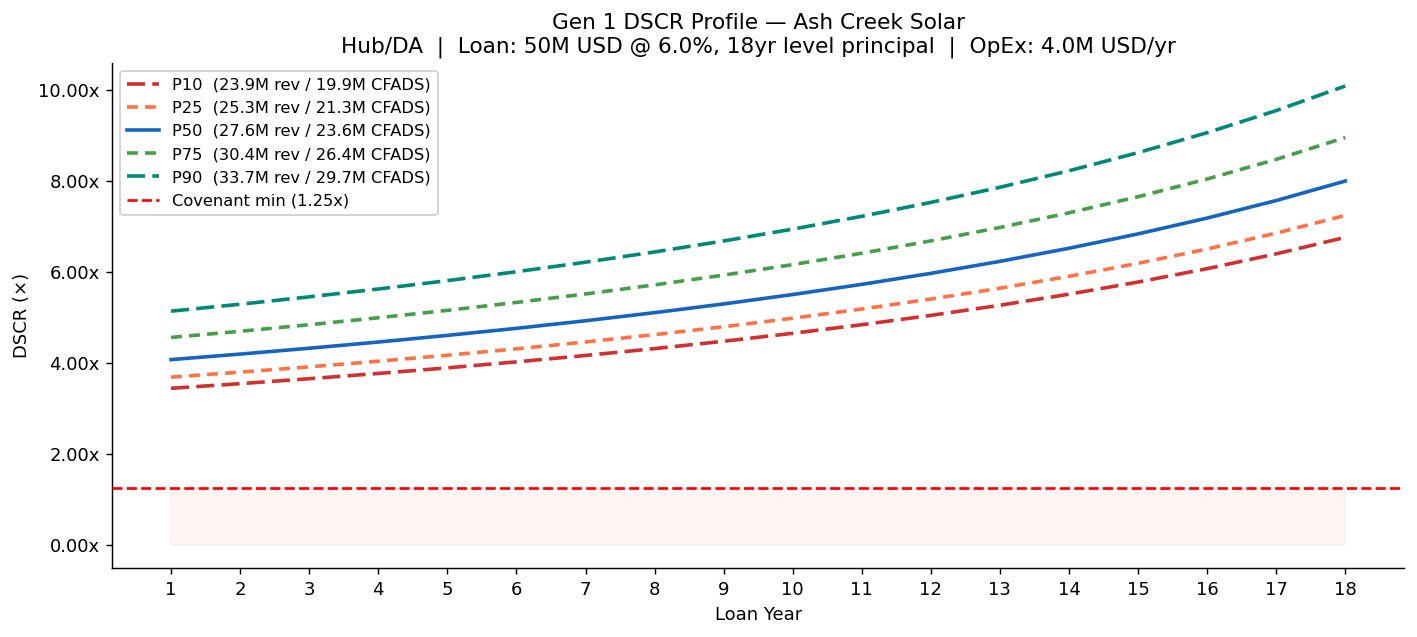

In [25]:
COLORS = {
    "P10": "#D32F2F",  # red — downside
    "P25": "#FF7043",  # orange
    "P50": "#1565C0",  # blue — median
    "P75": "#43A047",  # green
    "P90": "#00897B",  # teal — upside
}
LINESTYLES = {
    "P10": (5, 2),
    "P25": (3, 2),
    "P50": None,
    "P75": (3, 2),
    "P90": (5, 2),
}

fig, ax = plt.subplots(figsize=(11, 5))

for label in [f"P{p}" for p in PERCENTILES]:
    ls = LINESTYLES[label]
    kwargs = dict(color=COLORS[label], linewidth=2,
                  label=f"{label}  ({pct_revenue[label]/1e6:.1f}M rev / {pct_cfads[label]/1e6:.1f}M CFADS)")
    if ls:
        kwargs["dashes"] = ls
    ax.plot(dscr_df.index, dscr_df[label], **kwargs)

    # Mark breach regions
    breach_years = dscr_df.index[dscr_df[label] < MIN_DSCR]
    if len(breach_years):
        ax.scatter(breach_years, dscr_df.loc[breach_years, label],
                   color=COLORS[label], marker="x", s=80, zorder=5)

# Covenant line
ax.axhline(MIN_DSCR, color="red", linewidth=1.5, linestyle="--", zorder=3,
           label=f"Covenant min ({MIN_DSCR}x)")
ax.fill_between(dscr_df.index, 0, MIN_DSCR, alpha=0.04, color="red")

ax.set_xlabel("Loan Year")
ax.set_ylabel("DSCR (×)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}x"))
ax.set_xticks(dscr_df.index)
title_line2 = (
    f"Hub/DA  |  Loan: {LOAN_PRINCIPAL/1e6:.0f}M USD @ {ANNUAL_RATE*100:.1f}%, "
    f"{TENOR_YEARS}yr {AMORT_TYPE.replace('_',' ')}  |  "
    f"OpEx: {ANNUAL_OPEX/1e6:.1f}M USD/yr"
)
ax.set_title(f"Gen 1 DSCR Profile — {SITE.replace('_', ' ').title()}\n{title_line2}")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

### 6a. Revenue distribution with percentile markers

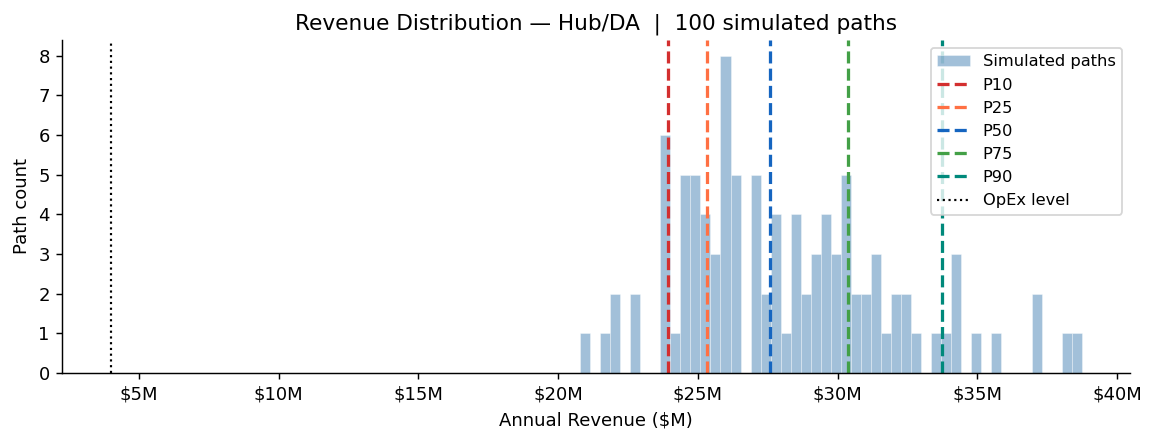

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.5))

ax.hist(sim_df["annual_revenue_usd"] / 1e6, bins=50,
        color="steelblue", alpha=0.5, edgecolor="white", linewidth=0.4, label="Simulated paths")

for label in [f"P{p}" for p in PERCENTILES]:
    ax.axvline(pct_revenue[label] / 1e6, color=COLORS[label], linewidth=1.8,
               linestyle="--", label=label)

ax.axvline((ANNUAL_OPEX) / 1e6, color="black", linewidth=1.2, linestyle=":", label="OpEx level")

ax.set_xlabel("Annual Revenue ($M)")
ax.set_ylabel("Path count")
ax.set_title(f"Revenue Distribution — Hub/DA  |  {len(sim_df):,} simulated paths")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
plt.tight_layout()
plt.show()

---
## 7. Gen 1 Assumptions and Caveats

These assumptions are **explicit and large**. Document them clearly;  
they define what Gen 2 relaxes (see `docs/From_Forecast_to_Cashflow_and_DSCR.md §5.4–5.5`).

| # | Assumption | Implication |
|---|-----------|-------------|
| A1 | **Revenue held constant** — Year 1 P10–P90 repeats every year | Ignores PPA escalation (+) and degradation (−) |
| A2 | **No degradation** — same MWh in Year 18 as Year 1 | Solar ~0.5%/yr; overestimates late-year revenue |
| A3 | **No price escalation** — $/MWh flat | CPI-linked PPAs typically +2%/yr; underestimates late-year revenue |
| A4 | **Flat OpEx** — no inflation | O&M typically escalates 2–3%/yr; overestimates late-year CFADS |
| A5 | **Years independent** — each year is P-case, no path dynamics | Cannot compute breach probability across years |
| A6 | **Annual covenant testing** — one DSCR per year | Misses within-year seasonality (H2 could breach if annual passes) |
| A7 | **No reserve mechanics** — CFADS = Revenue − OpEx only | Ignores DSRA top-up/drawdown in waterfall |
| A8 | **Hub + DA only** — no node prices, no RT | Capture price vs hub price difference not modeled |

**Net effect on DSCR accuracy:** Year 1 is the most reliable (all effects cancel at t=0).  
Accuracy decreases for later years, but since Year 1 is always the binding constraint  
in Gen 1, this is acceptable for a first-pass bankability check.

**What Gen 1 tells you:**
- Whether the project can service debt under each weather scenario
- Which percentile is the binding constraint in Year 1
- How much DSCR headroom builds with amortization
- Whether the loan is roughly bankable at this sizing

**What Gen 2 adds:** degradation, PPA escalation, OpEx inflation, Monte Carlo paths  
(1,000+ draws per year → breach probability), semi-annual DSCR, reserve mechanics.

In [29]:
# ── Final summary printout — covenant test every year ─────────────────────────
labels  = [f"P{p}" for p in PERCENTILES]
C       = 9   # fixed width for each DSCR cell (e.g. '  3.45x  ')
SEP     = "  "
W       = 62  # total rule width

def rule(ch="="): return ch * W

print(rule())
print(f"  GEN 1 DSCR SUMMARY — {SITE.replace('_', ' ').title()}")
print(rule())
print(f"  Site     : {SITE}")
print(f"  Filter   : Hub / DA  |  {len(sim_df):,} eligible simulated paths")
print(f"  Loan     : {LOAN_PRINCIPAL/1e6:.0f}M USD @ {ANNUAL_RATE*100:.1f}%  |  {TENOR_YEARS}yr  |  {AMORT_TYPE}")
print(f"  OpEx     : {ANNUAL_OPEX/1e6:.1f}M USD/yr  (flat — Gen 1)")
print(f"  Covenant : DSCR >= {MIN_DSCR}x  tested every year")
print(rule("-"))

# ── Revenue / CFADS reference block ──────────────────────────────────────────
hdr_pcts = SEP.join(f"{l:^{C}}" for l in labels)
print(f"  {'':10}{hdr_pcts}")
print(f"  {'Revenue':10}" + SEP.join(f"{pct_revenue[l]/1e6:>{C-2}.2f}M " for l in labels))
print(f"  {'CFADS':10}" + SEP.join(f"{pct_cfads[l]/1e6:>{C-2}.2f}M " for l in labels))
print(rule("-"))

# ── Year-by-year covenant table ───────────────────────────────────────────────
print(f"  {'Yr':>3}  {'DS(M)':>6}  {hdr_pcts}")
print(rule("-"))

total_breaches = 0
for yr in dscr_df.index:
    ds_val = loan_schedule.loc[yr, 'debt_service'] / 1e6
    cells, year_breach = [], False
    for label in labels:
        d = dscr_df.loc[yr, label]
        if d < MIN_DSCR:
            year_breach = True
            total_breaches += 1
            cells.append(f"{d:>{C-2}.2f}x*")
        else:
            cells.append(f"{d:>{C-2}.2f}x ")
    suffix = "  << BREACH" if year_breach else ""
    print(f"  {yr:>3}  {ds_val:>6.3f}  {SEP.join(cells)}{suffix}")

print(rule("-"))
print(f"  * = breach (DSCR < {MIN_DSCR}x)")
print()
if total_breaches == 0:
    print(f"  RESULT  No covenant breaches across all {TENOR_YEARS} years x {len(labels)} percentiles.")
else:
    print(f"  RESULT  {total_breaches} breach(es) found — see flagged rows above.")
print(rule())

  GEN 1 DSCR SUMMARY — Ash Creek Solar
  Site     : ash_creek_solar
  Filter   : Hub / DA  |  100 eligible simulated paths
  Loan     : 50M USD @ 6.0%  |  18yr  |  level_principal
  OpEx     : 4.0M USD/yr  (flat — Gen 1)
  Covenant : DSCR >= 1.25x  tested every year
--------------------------------------------------------------
               P10        P25        P50        P75        P90   
  Revenue     23.92M     25.34M     27.57M     30.38M     33.72M 
  CFADS       19.92M     21.34M     23.57M     26.38M     29.72M 
--------------------------------------------------------------
   Yr   DS(M)     P10        P25        P50        P75        P90   
--------------------------------------------------------------
    1   5.778     3.45x      3.69x      4.08x      4.57x      5.14x 
    2   5.611     3.55x      3.80x      4.20x      4.70x      5.30x 
    3   5.444     3.66x      3.92x      4.33x      4.85x      5.46x 
    4   5.278     3.77x      4.04x      4.47x      5.00x      5.63x 
 